# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit, prange

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro ($z \mapsto z + \frac{1}{z}$)

In [3]:
@njit
def R_njit(z):
    return z + 1/z

## Analizar iteraciones en diferentes regiones del plano

Veamos iteraciones en ciertas regiones del plano. Empezando por el eje real con $x > 1$.

In [4]:
generate_orbit_jitted = make_generate_orbit_jitted(R_njit)

In [23]:
z0 = 1.1
max_iter = 100

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

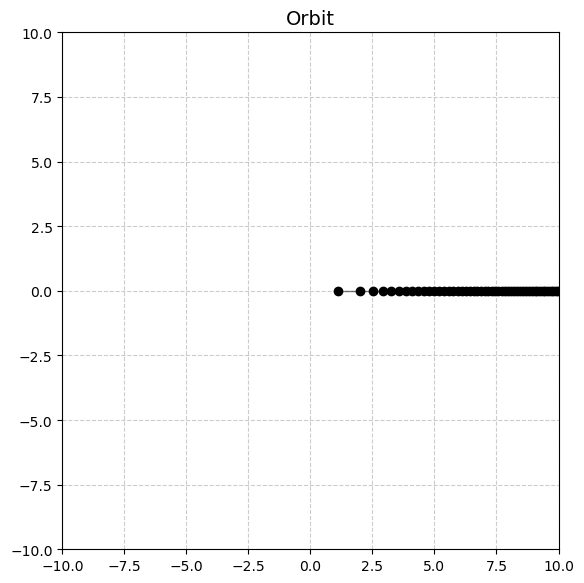

In [24]:
center = 0.0
max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [7]:
i = 0
while (i < len(orbit) and orbit[i].real < 1e10):
    print(orbit[i])
    i += 1

(1.1+0j)
(2.0090909090909093+0j)
(2.5068284656519952+0j)
(2.90573888720727+0j)
(3.2498854326531026+0j)
(3.557588587340507+0j)
(3.838677863250163+0j)
(4.099184223935848+0j)
(4.343135201830626+0j)
(4.573383617670525+0j)
(4.792040105645036+0j)
(5.00071949437177+0j)
(5.200690718737681+0j)
(5.392972870105974+0j)
(5.5783993545489325+0j)
(5.757662246364762+0j)
(5.931343847891732+0j)
(6.099939705027117+0j)
(6.263875751669656+0j)
(6.423521319309379+0j)
(6.579199171112245+0j)
(6.731193353685525+0j)
(6.8797554209826215+0j)
(7.025109425421514+0j)
(7.167455962598762+0j)
(7.306975480433012+0j)
(7.443831010149493+0j)
(7.578170438145174+0j)
(7.710128409816864+0j)
(7.8398279357971+0j)
(7.967381755624439+0j)
(8.092893502227277+0j)
(8.2164587017106+0j)
(8.338165636085115+0j)
(8.45809609125289+0j)
(8.576326008389227+0j)
(8.692926053562628+0j)
(8.807962117810543+0j)
(8.921495757785891+0j)
(9.033584585393895+0j)
(9.144282613463158+0j)
(9.253640563372503+0j)
(9.361706139634258+0j)
(9.46852427567533+0j)
(9.57

En este caso la parte real crece lentamente hacia $\infty$. Ahora veamos que ocurre en el eje imaginario cuando $y > 1$.

In [8]:
z0 = 0 + 2j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

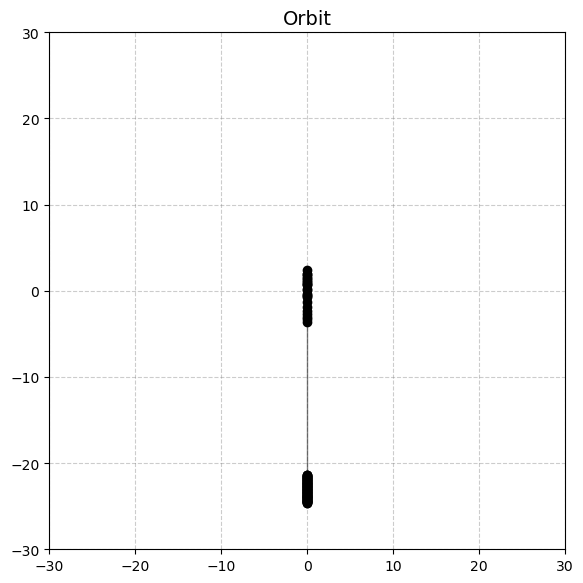

In [ ]:
max_distance_to_center = 30

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [10]:
i = 0
while (i < len(orbit) and abs(orbit[i]) < 1e10):
    print(orbit[i])
    i += 1

2j
1.5j
0.8333333333333334j
-0.3666666666666666j
2.3606060606060613j
1.9369860349321204j
1.4207200516128116j
0.7168516161213909j
-0.6781372177053588j
0.7964905919638134j
-0.4590170186589526j
1.7195514425313612j
1.1380044324995504j
0.25927323300539107j
-3.597661740221124j
-3.319703423901331j
-3.0184716955486834j
-2.687178212997665j
-2.3150406319607693j
-1.8830827707490503j
-1.3520386682095633j
-0.6124148515888083j
1.0204652090525475j
0.040519992763937696j
-24.638655194305393j
-24.598068563577627j
-24.557414965210125j
-24.516694066800554j
-24.475905533188506j
-24.43504902642335j
-24.39412420573162j
-24.353130727483894j
-24.312068245161182j
-24.270936409320804j
-24.22973486756175j
-24.188463264489492j
-24.147121241680292j
-24.105708437644925j
-24.064224487791854j
-24.022669024389852j
-23.981041676530015j
-23.939342070087203j
-23.89756982768086j
-23.855724568635246j
-23.813805908939j
-23.771813461204108j
-23.729746834624187j
-23.687605634932122j
-23.645389464357024j
-23.603097921580474j
-2

Inicialmente, puntos en el eje imaginario $y > 1$ se alejan del $\infty$. Sin embargo, una vez entran en la región $y < 1$ su comportamiento cambia. En $y < -1$ también parece que se alejan del $\infty$. Por último, analicemos que ocurre con $z_0 = x_0 + i y_0$, con $x_0 > 1$.

In [30]:
z0 = 2 + 2j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

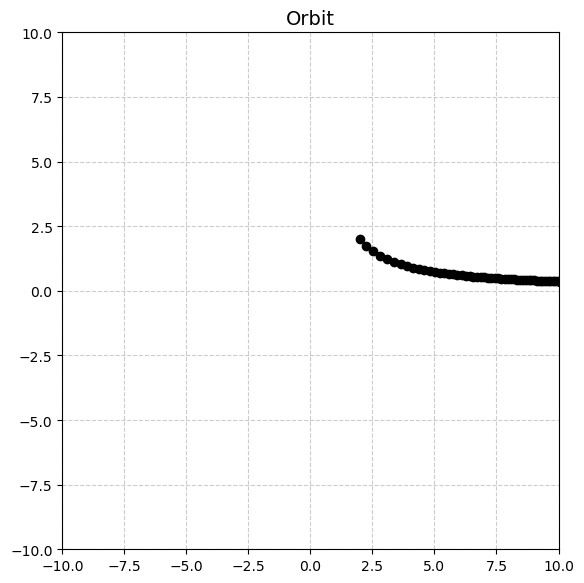

In [34]:
max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

Veamos con $x > 1$ e $y$ aleatorios que comportamientos encontramos.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

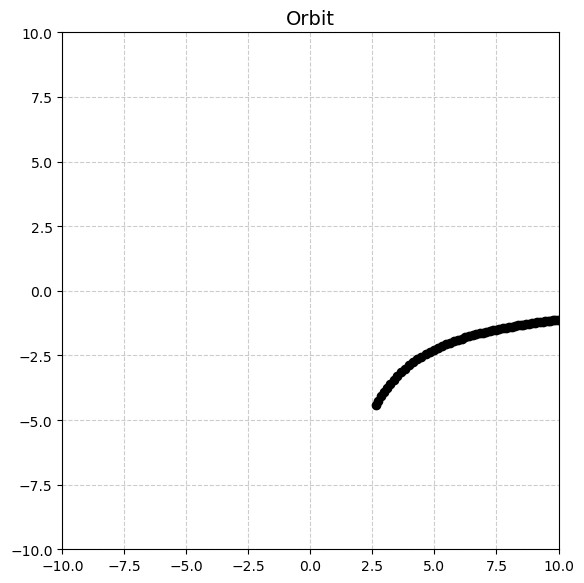

In [201]:
x0 = np.random.uniform(1, 5)
y0 = np.random.uniform(-5, 5)
z0 = x0 + y0*1j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

El comportamiento siempre es tender hacia $y = 0$, $x = \infty$. Ahora veamos en general en comportamiento con puntos aleatorios cerca del origen.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

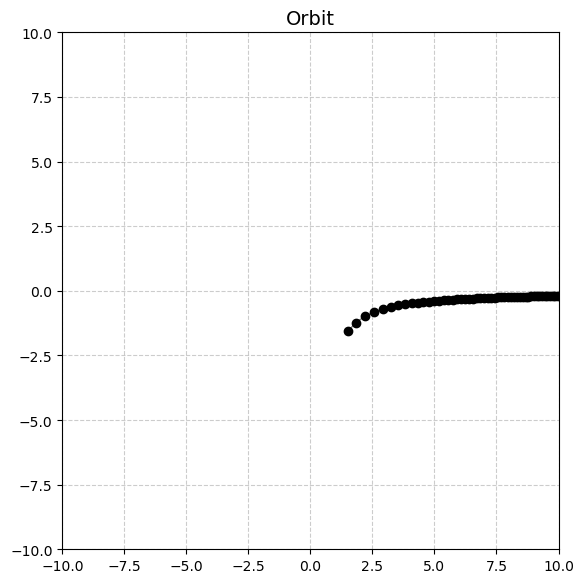

In [264]:
x0 = np.random.uniform(-2, 2)
y0 = np.random.uniform(-2, 2)
z0 = x0 + y0*1j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

Parece que siempre se comporta parecido. A la izquierda del eje imaginario tiende a $y = 0$, $x = -\infty$ y a la derecha $y = 0$, $x = \infty$. Veamos que ocurre en el eje imaginario.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

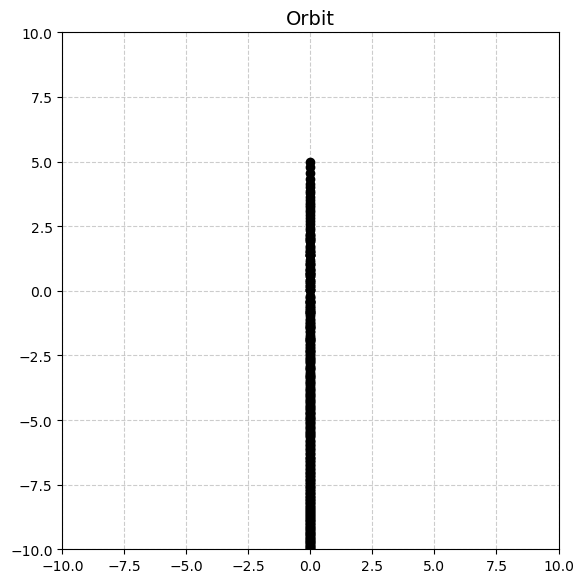

In [299]:
x0 = 0
y0 = np.random.uniform(-2, 2)
z0 = x0 + y0*1j

max_iter = 1000

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [300]:
i = 0
while (i < len(orbit)-1 and abs(orbit[i]) < 1e10):
    if (abs(orbit[i]) < abs(orbit[i+1])):
        print(f"{i+1}: {abs(orbit[i])}\tto {abs(orbit[i+1])}")
        print(f"")
    i += 1

print(f"max = {max(abs(orbit))}")

2: 0.6734396383711754	to 0.8114744400734268

4: 0.4208502649530361	to 1.9552917581762421

8: 0.5798071805881952	to 1.1449041259974406

10: 0.2714685454165777	to 3.4121994775783735

18: 0.23426271775906693	to 4.034448964432181

28: 0.32573643388495754	to 2.744230250754245

34: 0.5575451995688931	to 1.236031358480971

36: 0.4269903959369813	to 1.9149826543130484

39: 0.6747986589020029	to 0.8071248553313356

41: 0.4318408305779239	to 1.8838271868759144

44: 0.6138907717660134	to 1.0150635080372894

46: 0.029903474126126484	to 33.41102702720001

607: 0.3923389375529772	to 2.1564776704467596

611: 0.19457138323339118	to 4.944930548561406

625: 0.5249503764208188	to 1.3799915855568685

627: 0.6553494859483628	to 0.8705539006284801

629: 0.27814005074899195	to 3.317171006781705

636: 0.6041819800521587	to 1.0509484823189146

638: 0.09942705493790438	to 9.958197608937883

690: 0.19351158371852328	to 4.97413771553259

704: 0.6648840052909113	to 0.8391377369112689

706: 0.35256173745731245	to 2

## Analizar tiempos de escape

Veamos qué regiones del plano escapan a $\infty$ (espero que sea casi todo, ya que el único punto fijo es el $\infty$ aunque es indiferente).

In [11]:
generate_escape_time_fractal_jitted = make_generate_escape_time_fractal_jitted(R_njit)

In [313]:
center = 0.0
max_distance_to_center = 3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 1e4

escape_times = generate_escape_time_fractal_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=10)

In [314]:
escape_times

array([[49, 49, 49, ..., 49, 49, 49],
       [49, 49, 49, ..., 49, 49, 49],
       [49, 49, 49, ..., 49, 49, 49],
       ...,
       [49, 49, 49, ..., 49, 49, 49],
       [49, 49, 49, ..., 49, 49, 49],
       [49, 49, 49, ..., 49, 49, 49]], shape=(1000, 1000))

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Escape Time Fractal'}>)

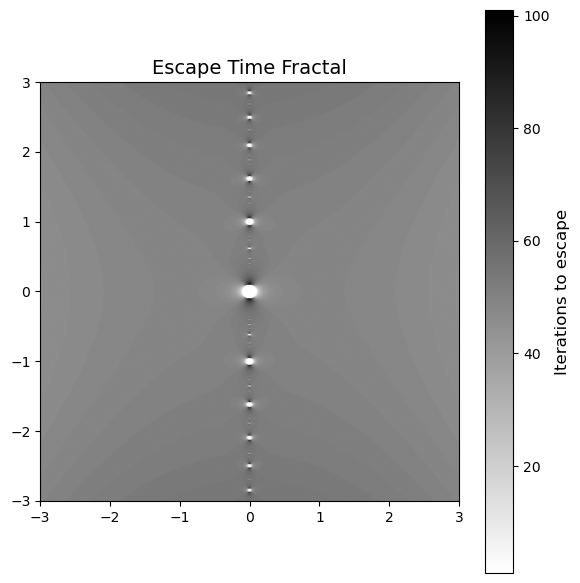

In [315]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The escape time fractal
plotter.plot_escape_time_fractal(escape_times, show_colorbar=True)

# Función conjugada por $\frac{1}{z}$ ($\frac{z}{1+z^2}$)

In [316]:
@njit
def R_njit(z):
    return z / (1 + z**2)

## Analizar iteraciones en diferentes regiones del plano

Veamos iteraciones en ciertas regiones del plano. Empezando por el eje real con $x < 1$.

In [317]:
generate_orbit_jitted = make_generate_orbit_jitted(R_njit)

In [318]:
z0 = 0.9
max_iter = 100

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

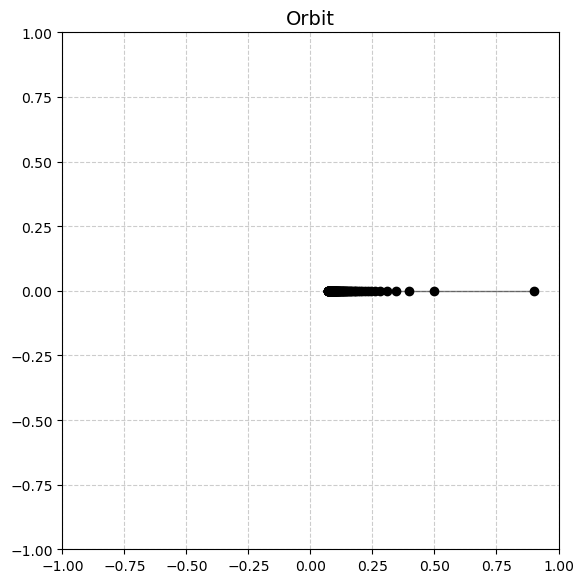

In [319]:
center = 0.0
max_distance_to_center = 1

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [321]:
i = 0
while (i < len(orbit)):
    print(orbit[i])
    i += 1

(0.9+0j)
(0.4972375690607735+0j)
(0.39866865715474414+0j)
(0.34399519643719323+0j)
(0.30759647636370746+0j)
(0.28100867421907727+0j)
(0.26044259668789693+0j)
(0.243898853054835+0j)
(0.23020474390573162+0j)
(0.2186191895770722+0j)
(0.20864703991423614+0j)
(0.19994281205752576+0j)
(0.19225693205779357+0j)
(0.18540389821208045+0j)
(0.17924250772517347+0j)
(0.17366308167149191+0j)
(0.16857893225406825+0j)
(0.16392049912833656+0j)
(0.15963121943090883+0j)
(0.15566455557815329+0j)
(0.1519818152342376+0j)
(0.1485505250663576+0j)
(0.145343199120513+0j)
(0.14233639326665298+0j)
(0.13950997025840065+0j)
(0.13684652204785852+0j)
(0.13433091102684497+0j)
(0.13194990226732983+0j)
(0.12969186614498918+0j)
(0.12754653594297077+0j)
(0.12550480879955125+0j)
(0.12355858111815694+0j)
(0.1217006115958945+0j)
(0.11992440654988415+0j)
(0.1182241233704231+0j)
(0.11659448880584576+0j)
(0.11503072945687583+0j)
(0.1135285123794617+0j)
(0.11208389410182512+0j)
(0.11069327668113563+0j)
(0.10935336967817573+0j)
(0

En este caso la parte real decrece lentamente hacia $0$. Ahora veamos que ocurre en el eje imaginario cuando $y < 1$.

In [322]:
z0 = 0 + 0.5j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

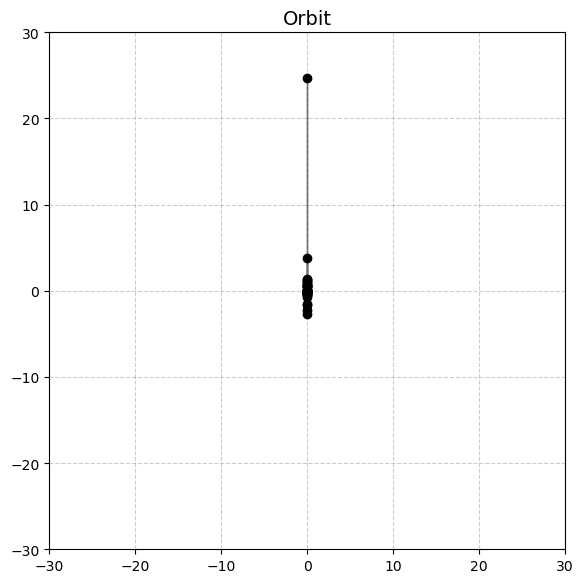

In [323]:
max_distance_to_center = 30

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [324]:
i = 0
while (i < len(orbit) and abs(orbit[i]) < 1e10):
    print(orbit[i])
    i += 1

0.5j
0.6666666666666666j
1.2j
(-0-2.7272727272727275j)
(-0+0.4236200256739409j)
0.5162659833193088j
0.7038684354914209j
1.394988833826751j
(-0-1.474627809669168j)
(-0+1.255507610622776j)
-2.178568461190237j
(-0+0.5815470100318422j)
0.8787311994942556j
3.856934973229801j
(-0-0.277958316319522j)
(-0-0.3012317283523048j)
(-0-0.33129348255056584j)
(-0-0.3721375810362626j)
(-0-0.4319578612107473j)
(-0-0.5310441025377446j)
(-0-0.739623816616422j)
(-0-1.6328800606086824j)
(-0+0.9799452163317531j)
24.6791752407098j
(-0-0.04058663063925926j)
(-0-0.04065359827855932j)
(-0-0.040720898320184544j)
(-0-0.040788533522215974j)
(-0-0.040856506674872596j)
(-0-0.040924820600994366j)
(-0-0.040993478156534084j)
(-0-0.041062482231058385j)
(-0-0.04113183574825803j)
(-0-0.04120154166646769j)
(-0-0.04127160297919541j)
(-0-0.041342022715662056j)
(-0-0.04141280394135085j)
(-0-0.041483949758567305j)
(-0-0.041555463307009745j)
(-0-0.041627347764350675j)
(-0-0.041699606346829246j)
(-0-0.04177224230985502j)
(-0-0.04

Inicialmente, puntos en el eje imaginario $y < 1$, $y > 0$ se alejan del $0$. Sin embargo, una vez entran en la región $y > 1$ su comportamiento cambia. En $y > -1$, $y < 0$ también parece que se alejan del $0$. Por último, analicemos que ocurre con $z_0 = x_0 + i y_0$, con $x_0 < 1$.

In [326]:
z0 = 0.5 + 0.5j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

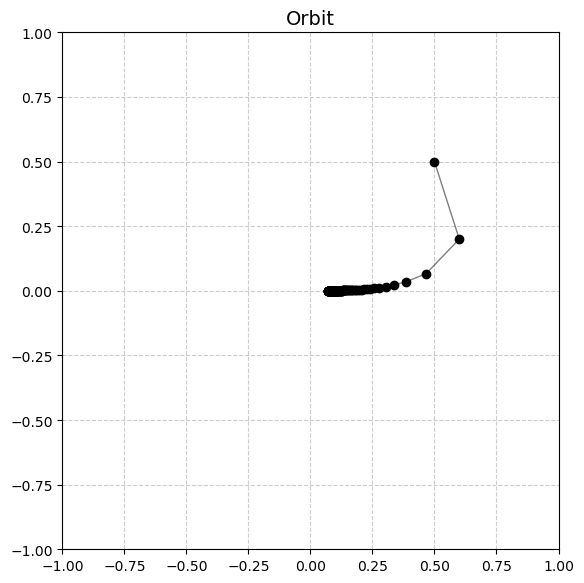

In [328]:
max_distance_to_center = 1

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

Veamos con $x > 1$ e $y$ aleatorios que comportamientos encontramos.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

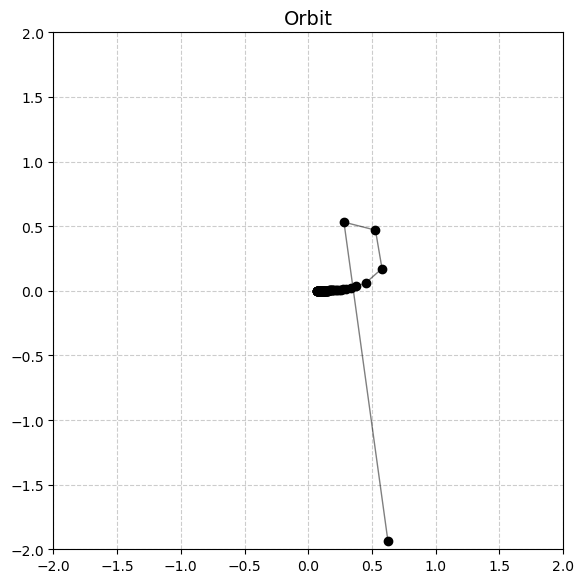

In [360]:
x0 = np.random.uniform(0, 1)
y0 = np.random.uniform(-2, 2)
z0 = x0 + y0*1j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

El comportamiento siempre es tender hacia $y = 0$, $x = 0$. Ahora veamos en general en comportamiento con puntos aleatorios cerca del origen.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

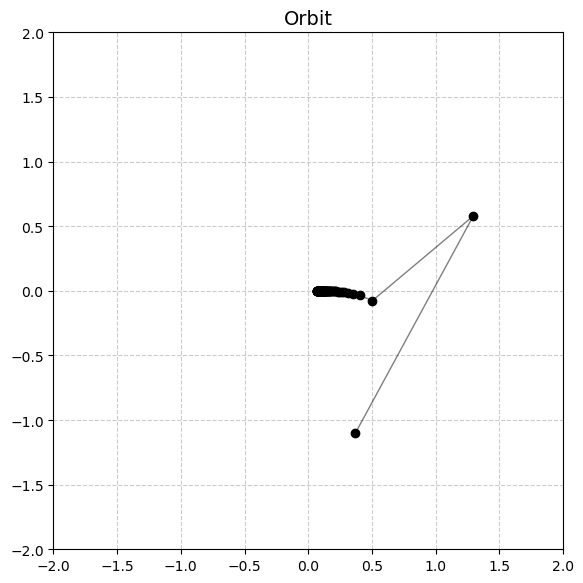

In [392]:
x0 = np.random.uniform(-2, 2)
y0 = np.random.uniform(-2, 2)
z0 = x0 + y0*1j

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

Parece que siempre se comporta parecido. Tanto a la izquierda del eje imaginario tiende a $y = 0$, $x = -0$ y a la derecha $y = 0$, $x = 0$. Veamos que ocurre en el eje imaginario.

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Orbit'}>)

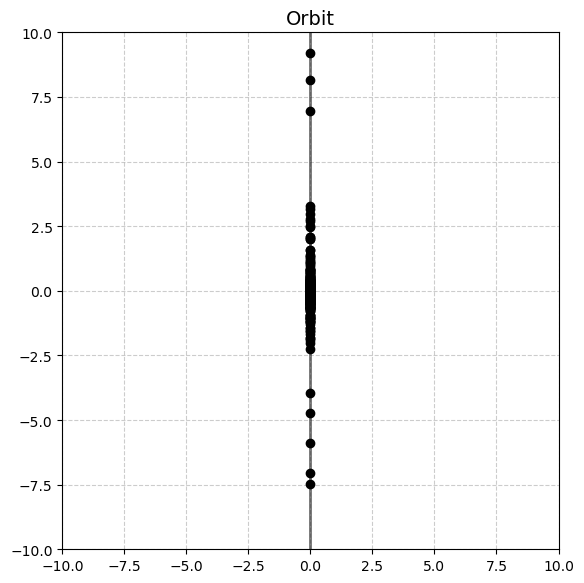

In [401]:
x0 = 0
y0 = np.random.uniform(-2, 2)
z0 = x0 + y0*1j

max_iter = 1000

orbit = generate_orbit_jitted(z0, max_iter=max_iter)

max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_orbit(orbit)

In [406]:
i = 0
while (i < len(orbit)-1 and abs(orbit[i]) < 1e10):
    if (abs(orbit[i]) > abs(orbit[i+1])):
        print(f"{i+1}: {abs(orbit[i])}\tto {abs(orbit[i+1])}")
        print(f"")
    i += 1

print(f"min = {min(abs(orbit))}")

1: 1.8198869818183372	to 0.7871522207706813

3: 2.0693219126219757	to 0.6304884719472582

6: 11.001361921117953	to 0.09165512963223185

68: 5.875246978461809	to 0.1752835668556848

86: 1.5683741073884478	to 1.0743779726355036

88: 6.963456503883514	to 0.1466307982759064

113: 1.4279386910302512	to 1.3743276729291825

115: 1.5463140526618624	to 1.111586756633196

117: 4.717607224229625	to 0.22194428092667604

129: 2.5060316656281505	to 0.47460970734554314

133: 25.520487799459502	to 0.03924446001177172

461: 1.6641816901985798	to 0.9404809458887899

463: 8.143003057239634	to 0.12468519730329188

497: 1.451940715656926	to 1.3102598995094203

499: 1.8279779900942974	to 0.7806855573362196

501: 1.9990408835711408	to 0.6671999865615904

504: 2.6961536035025717	to 0.43006038597395396

508: 1.5715701628288656	to 1.0692169801545408

510: 7.465298296813209	to 0.1364006162454984

539: 2.785719601057678	to 0.412074452814052

544: 3.294592802173194	to 0.33432905938615126

550: 1.8905474581560444	t

## Analizar tiempos de escape

Veamos qué regiones del plano escapan a $\infty$ (espero que sea casi todo, ya que el único punto fijo es el $\infty$ aunque es indiferente).

In [407]:
generate_escape_time_fractal_jitted = make_generate_escape_time_fractal_jitted(R_njit)

In [413]:
center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 1e2

escape_times = generate_escape_time_fractal_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=3)

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Escape Time Fractal'}>)

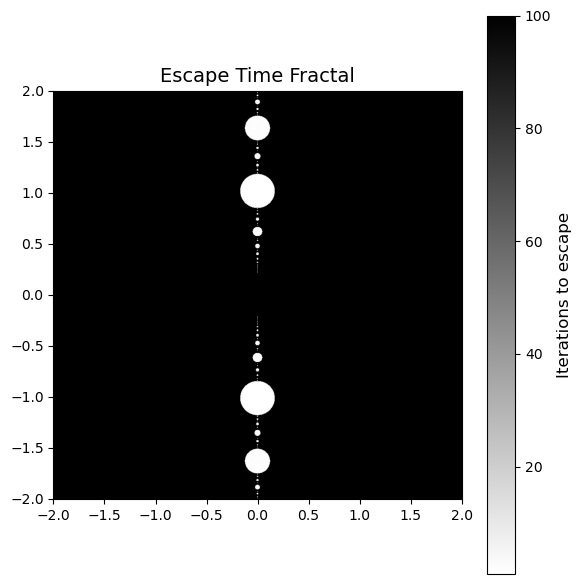

In [414]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The escape time fractal
plotter.plot_escape_time_fractal(escape_times, show_colorbar=True)